#### Import libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

#### Define useful functions

In [2]:
def import_csv(file_path):
    try:
        data = pd.read_csv(file_path)
        return data
    except Exception as e:
        print(f"Error importing CSV file: {e}")
        return None

#### Analyze data

In [3]:
dataset = import_csv('dataset/train.csv')

In [4]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [5]:
dataset.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


#### Clean data

In [6]:
dataset.drop(columns=['PassengerId', 'Name', 'SibSp', 'Parch', 'Ticket', 'Cabin'], inplace=True)
# sex 'male' -> 0, 'female' -> 1
dataset['Sex'] = dataset['Sex'].map({'male': 0, 'female': 1})
# fill missing values in 'Age' with the median age
dataset['Age'].fillna(dataset['Age'].median(), inplace=True)
# fill missing values in 'Embarked' with the mode
dataset['Embarked'].fillna(dataset['Embarked'].mode()[0], inplace=True)
dataset['Embarked'] = dataset['Embarked'].map({'S': 0, 'C': 1, 'Q': 2})

# lowercase every column name
dataset.columns = dataset.columns.str.lower()

In [7]:
dataset.head()

,survived,pclass,sex,age,fare,embarked
0,0,3,0,22.0,7.2500,0
1,1,1,1,38.0,71.2833,1
2,1,3,1,26.0,7.9250,0
3,1,1,1,35.0,53.1000,0
4,0,3,0,35.0,8.0500,0


##### Passenger fare Discretization

<AxesSubplot:>

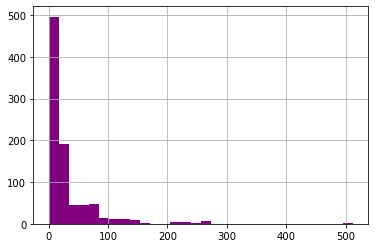

In [8]:
dataset['fare'].hist(bins=30, color='purple')

In [9]:
# discretize fare into 4 bins in intervals (0-15], (15-30], (30-80], (80-200], (200+])
dataset['fare_bin'] = pd.cut(dataset['fare'], bins=[-1, 15, 30, 80, 200, np.inf], labels=[0, 1, 2, 3, 4])

In [10]:
dataset['fare_bin'].value_counts().sort_index()

0    458
1    199
2    160
3     54
4     20
Name: fare_bin, dtype: int64

In [11]:
dataset.drop(columns=['fare'], inplace=True)

##### Age Discretization

<AxesSubplot:>

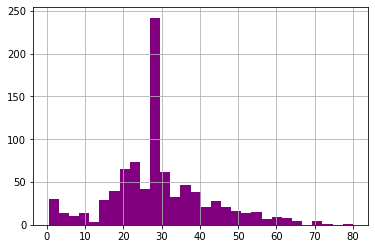

In [12]:
dataset['age'].hist(bins=30, color='purple')

In [13]:
# discretize age into 10 bins (0-14], (14-30], (30-45], (45-60], (60+]))
dataset['age_bin'] = pd.cut(dataset['age'], bins=[-1, 14, 30, 45, 60, np.inf], labels=[0, 1, 2, 3, 4])

In [14]:
dataset.head(10)

,survived,pclass,sex,age,embarked,fare_bin,age_bin
0,0,3,0,22.0,0,0,1
1,1,1,1,38.0,1,2,2
2,1,3,1,26.0,0,0,1
3,1,1,1,35.0,0,2,2
4,0,3,0,35.0,0,0,2
5,0,3,0,28.0,2,0,1
6,0,1,0,54.0,0,2,3
7,0,3,0,2.0,0,1,0
8,1,3,1,27.0,0,0,1
9,1,2,1,14.0,1,2,0


#### Visualize data

In [15]:
total_cases = np.array([
    dataset[dataset['pclass'] == i].shape[0]
    for i in range(1, 4)
])

total_cases

array([216, 184, 491])

In [16]:
survived = np.array([
    dataset[(dataset['survived'] == 1) & (dataset['pclass'] == i)].shape[0]
    for i in range(1, 4)
])

survived

array([136,  87, 119])

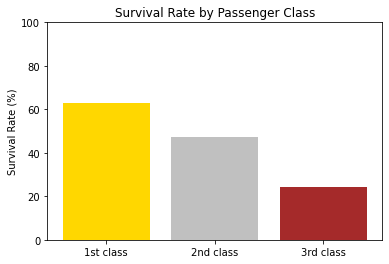

In [17]:
plt.bar(['1st class', '2nd class', '3rd class'], survived / total_cases * 100, color=['gold', 'silver', 'brown'])
plt.title('Survival Rate by Passenger Class')
plt.ylabel('Survival Rate (%)')
plt.ylim(0, 100)
plt.show()

Total cases by sex:	[577 314]
Survived by sex:	[109 233]


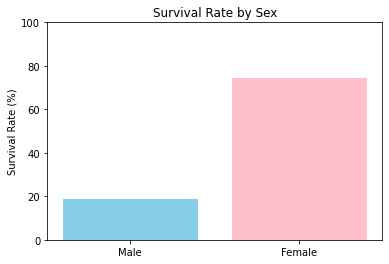

In [18]:
total_cases = np.array([
    dataset[dataset['sex'] == i].shape[0]
    for i in range(2)
])

survived = np.array([
    dataset[(dataset['survived'] == 1) & (dataset['sex'] == i)].shape[0]
    for i in range(2)
])

print("Total cases by sex:", total_cases, sep='\t')
print("Survived by sex:", survived, sep='\t')

plt.bar(['Male', 'Female'], survived / total_cases * 100, color=['skyblue', 'pink'])
plt.title('Survival Rate by Sex')
plt.ylabel('Survival Rate (%)')
plt.ylim(0, 100)
plt.show()

##### WARNING ⚠️

`men` contains child but they are classifiable as an alternernative category.

`sex` feature could be trasformed into `who` $\rightarrow$ ```("men" (0), "woman" (1), "child" (2))```

In [19]:
GAP_AGE = 14

dataset['who'] = dataset.apply(
    lambda row: 2 if row['age'] <= GAP_AGE else row['sex'],
    axis=1
)

In [20]:
dataset.head()

,survived,pclass,sex,age,embarked,fare_bin,age_bin,who
0,0,3,0,22.0,0,0,1,0.0
1,1,1,1,38.0,1,2,2,1.0
2,1,3,1,26.0,0,0,1,1.0
3,1,1,1,35.0,0,2,2,1.0
4,0,3,0,35.0,0,0,2,0.0


Total cases by who:	[538 276  77]
Survived by who:	[ 88 209  45]


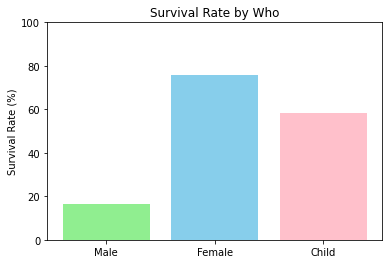

In [21]:
total_cases = np.array([
    dataset[dataset['who'] == i].shape[0]
    for i in range(3)
])

survived = np.array([
    dataset[(dataset['survived'] == 1) & (dataset['who'] == i)].shape[0]
    for i in range(3)
])

print("Total cases by who:", total_cases, sep='\t')
print("Survived by who:", survived, sep='\t')

plt.bar(['Male', 'Female', 'Child'], survived / total_cases * 100, color=['lightgreen', 'skyblue', 'pink'])
plt.title('Survival Rate by Who')
plt.ylabel('Survival Rate (%)')
plt.ylim(0, 100)
plt.show()

Total cases by port of embarkation:	[646 168  77]
Survived by port of embarkation:	[219  93  30]


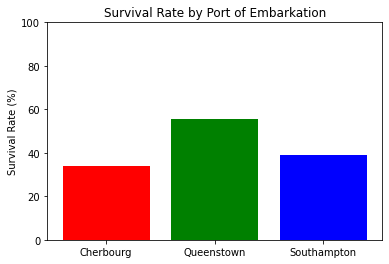

In [22]:
total_cases = np.array([
    dataset[dataset['embarked'] == i].shape[0]
    for i in range(3)
])

survived = np.array([
    dataset[(dataset['survived'] == 1) & (dataset['embarked'] == i)].shape[0]
    for i in range(3)
])

print("Total cases by port of embarkation:", total_cases, sep='\t')
print("Survived by port of embarkation:", survived, sep='\t')

plt.bar(['Cherbourg', 'Queenstown', 'Southampton'], survived / total_cases * 100, color=['red', 'green', 'blue'])
plt.title('Survival Rate by Port of Embarkation')
plt.ylabel('Survival Rate (%)')
plt.ylim(0, 100)
plt.show()

#### Entropy

In [23]:
def entropy(dataset, target_col):
    total = dataset.shape[0]
    if total == 0:
        return 0
    counts = dataset[target_col].value_counts()
    probabilities = counts / total
    entropy_value = -np.sum(probabilities * np.log2(probabilities))
    return entropy_value

In [24]:
e_total = entropy(dataset, 'survived')

print(f"Total entropy: {e_total:.4f}")

Total entropy: 0.9607


In [25]:
e_class = [entropy(dataset[dataset['pclass'] == i], 'survived') for i in [1, 2, 3]]
           
print(f"Total entropy: {e_total:.4f}")
for i in range(1, 4):
    print(f"Entropy for {i}st class: {e_class[i-1]:.4f}")

Total entropy: 0.9607
Entropy for 1st class: 0.9510
Entropy for 2st class: 0.9979
Entropy for 3st class: 0.7989


In [26]:
# WAE (Weighted Average Entropy)
wae_class = dataset['pclass'].value_counts().sort_index() @ e_class / dataset.shape[0]

# Information Gain
gain_class = e_total - wae_class

gain_class

0.08383104529601171

Let's automatize this entire process in a single function

In [27]:
def information_gain(dataset, target_col, feature_col):
    total_entropy = entropy(dataset, target_col)
    feature_values = dataset[feature_col].unique()
    
    weighted_entropy = 0
    for value in feature_values:
        subset = dataset[dataset[feature_col] == value]
        subset_entropy = entropy(subset, target_col)
        weight = subset.shape[0] / dataset.shape[0]
        weighted_entropy += weight * subset_entropy
    
    gain = total_entropy - weighted_entropy
    return gain

In [28]:
information_gain(dataset, 'survived', 'pclass')

0.0838310452960116

In [29]:
def bruteforce_information_gain(dataset, target_col):
    features = dataset.columns.drop(target_col)
    gains = {}
    for feature in features:
        gain = information_gain(dataset, target_col, feature)
        gains[feature] = gain
    return gains

In [30]:
bruteforce_information_gain(dataset, 'survived')

{'pclass': 0.0838310452960116,
 'sex': 0.2176601066606142,
 'age': 0.10812624245681024,
 'embarked': 0.02053423884010741,
 'fare_bin': 0.07861698561449171,
 'age_bin': 0.01698821300066833,
 'who': 0.2402689315371661}

In [31]:
max(bruteforce_information_gain(dataset, 'survived').items(), key=lambda x: x[1])

('who', 0.2402689315371661)

#### Decision Tree

In [52]:
class Node:
    def __init__(self, feature=None, value=None, children=None, depth=0):
        self.feature = feature
        self.children = children if children is not None else {}
        self.value = value
        self.depth = depth

    def is_leaf(self):
        return self.value is not None

    def __repr__(self):
        if self.is_leaf():
            return f"Leaf(val={self.value})"
        return f"Node(feat={self.feature}, branches={len(self.children)})"

    def __str__(self):
        indent = "  " * self.depth
        if self.is_leaf():
            return f"{indent} (Prediction): {'SURVIVED' if self.value == 1 else 'DIED'}"
        
        s = f"{indent}[ {self.feature.upper()} ]"
        for val, child in self.children.items():
            s += f"\n{indent} ↳ If {val}:\n{child}"
        return s

In [53]:
def build_tree(df, target, features, depth=0, max_depth=3):
    unique_classes = df[target].unique()
    
    if len(unique_classes) == 1:
        return Node(value=unique_classes[0], depth=depth)
    
    if depth >= max_depth or not features:
        majority_class = df[target].mode()[0]
        return Node(value=majority_class, depth=depth)
    
    gains = {f: information_gain(df, target, f) for f in features}
    best_feature = max(gains, key=gains.get)
    
    children = {}
    feature_values = df[best_feature].unique()
    
    remaining_features = [f for f in features if f != best_feature]
    
    for val in feature_values:
        subset = df[df[best_feature] == val]
        children[val] = build_tree(subset, target, remaining_features, depth + 1, max_depth)
        
    return Node(feature=best_feature, children=children, depth=depth)

In [54]:
features_list = ['who', 'pclass', 'embarked', 'fare_bin', 'age_bin']

root_node = build_tree(dataset, 'survived', features_list, max_depth=3)

#### Plot tree

In [55]:
from graphviz import Digraph

def visualize_tree(node, dot=None):
    if dot is None:
        dot = Digraph(comment='Titanic Decision Tree')
        dot.attr('node', shape='box', style='filled', color='lightblue', fontname='helvetica')

    node_id = str(id(node))

    if node.is_leaf():
        label = "SURVIVED" if node.value == 1 else "DIED"
        color = "#95e1d3" if node.value == 1 else "#f38181"
        dot.node(node_id, label, fillcolor=color, shape='ellipse')
    else:
        dot.node(node_id, node.feature.upper())
        for val, child in node.children.items():
            child_id = str(id(child))
            visualize_tree(child, dot)
            dot.edge(node_id, child_id, label=str(val))
    
    return dot

In [57]:
def plot_tree(node, indent=""):
    tree_graph = visualize_tree(root_node)
    tree_graph.render('tree/titanic_tree', view=True, format='png')

In [58]:
plot_tree(root_node)

#### Pruning

In [59]:
def prune(node): # in-place
    if node.is_leaf():
        return node

    for val in node.children:
        node.children[val] = prune(node.children[val])

    child_nodes = list(node.children.values())
    
    if all(child.is_leaf() for child in child_nodes):
        first_val = child_nodes[0].value
        if all(child.value == first_val for child in child_nodes):
            print(f"Prune on {node.feature}")
            node.value = first_val
            node.feature = None
            node.children = {}
            
    return node

In [60]:
prune(root_node)

Prune on fare_bin
Prune on age_bin
Prune on age_bin
Prune on pclass
Prune on fare_bin
Prune on embarked
Prune on embarked


Node(feat=who, branches=3)

In [61]:
plot_tree(root_node)

#### Test on training set

In [62]:
dataset.iloc[0]

survived     0.0
pclass       3.0
sex          0.0
age         22.0
embarked     0.0
fare_bin     0.0
age_bin      1.0
who          0.0
Name: 0, dtype: float64

In [63]:
def test(dataset, root_node):
    error = 0
    for row in dataset.iloc():
        node = root_node
        while not node.is_leaf():
            feature_value = row[node.feature]
            node = node.children.get(feature_value)
            if node is None:
                print("Value not found among children.")
                break
        if node.value != row['survived']:
            error += 1
    return 1 - error / len(dataset)

In [64]:
print(f'Accuracy: {test(dataset, root_node) * 100:.2f}%')

Accuracy: 82.72%


#### Prediction in Validation set

In [66]:
test_data = pd.read_csv('dataset/test.csv')

In [67]:
test_data.drop(columns=['Name', 'SibSp', 'Parch', 'Ticket', 'Cabin'], inplace=True)
# sex 'male' -> 0, 'female' -> 1
test_data['Sex'] = test_data['Sex'].map({'male': 0, 'female': 1})
# fill missing values in 'Age' with the median age
test_data['Age'].fillna(test_data['Age'].median(), inplace=True)
# fill missing values in 'Embarked' with the mode
test_data['Embarked'].fillna(test_data['Embarked'].mode()[0], inplace=True)
test_data['Embarked'] = test_data['Embarked'].map({'S': 0, 'C': 1, 'Q': 2})

test_data.columns = test_data.columns.str.lower()

test_data['fare_bin'] = pd.cut(test_data['fare'], bins=[-1, 15, 30, 80, 200, np.inf], labels=[0, 1, 2, 3, 4])
test_data.drop(columns=['fare'], inplace=True)

test_data['age_bin'] = pd.cut(test_data['age'], bins=[-1, 14, 30, 45, 60, np.inf], labels=[0, 1, 2, 3, 4])

GAP_AGE = 14

test_data['who'] = test_data.apply(
    lambda row: 2 if row['age'] <= GAP_AGE else row['sex'],
    axis=1
)

In [68]:
def predict(validation, root_node):
    predictions = []
    for _, row in validation.iterrows():
        node = root_node
        while not node.is_leaf():
            feature_value = row[node.feature]
            node = node.children.get(feature_value)
            if node is None:
                print("Value not found among children.")
                break
        predictions.append(node.value)
    return predictions

In [69]:
predictions = predict(test_data, root_node)

In [70]:
test_data['survived'] = predictions

In [71]:
test_data.head()

,passengerid,pclass,sex,age,embarked,fare_bin,age_bin,who,survived
0,892,3,0,34.5,2,0,2,0.0,0
1,893,3,1,47.0,0,0,3,1.0,0
2,894,2,0,62.0,2,0,4,0.0,0
3,895,3,0,27.0,0,0,1,0.0,0
4,896,3,1,22.0,0,0,1,1.0,0


In [72]:
to_submit = test_data[['passengerid', 'survived']].rename(columns={'passengerId': 'PassengerId', 'survived': 'Survived'})

In [75]:
to_submit.to_csv('submissions/submission.csv', index=False)

Accuracy on `test.csv` with `submission.csv` \
$0.77751$ ✅

Accuracy on `test.csv` with `gender_submission.csv` \
$0.76555$ 👍

#### Using official libraries

In [76]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

X_cols = ['pclass', 'who', 'fare_bin', 'embarked', 'age_bin']
y_col = 'survived'

# Scikit-Learn does not accept strings
df_encoded = dataset.copy()
for col in ['who', 'fare_bin', 'embarked', 'age_bin']:
    df_encoded[col] = df_encoded[col].astype('category').cat.codes

X = df_encoded[X_cols]
y = df_encoded[y_col]

sk_tree = DecisionTreeClassifier(criterion='entropy', max_depth=3)
sk_tree.fit(X, y)

sk_preds = sk_tree.predict(X)
acc_sk = accuracy_score(y, sk_preds)

acc_custom = test(dataset, root_node)

print(f"{'='*30}")
print(f"ACCURACY RESULTS TRAINING DATA")
print(f"{'='*30}")
print(f"Accuracy Custom      \t{acc_custom:.4f}")
print(f"Accuracy Scikit-Learn\t{acc_sk:.4f}")
print(f"{'='*30}")

ACCURACY RESULTS TRAINING DATA
Accuracy Custom      	0.8272
Accuracy Scikit-Learn	0.8137


In [77]:
test_data_sk = pd.read_csv('dataset/test.csv')

test_data_sk.drop(columns=['Name', 'SibSp', 'Parch', 'Ticket', 'Cabin'], inplace=True)
# sex 'male' -> 0, 'female' -> 1
test_data_sk['Sex'] = test_data_sk['Sex'].map({'male': 0, 'female': 1})
# fill missing values in 'Age' with the median age
test_data_sk['Age'].fillna(test_data_sk['Age'].median(), inplace=True)
# fill missing values in 'Embarked' with the mode
test_data_sk['Embarked'].fillna(test_data_sk['Embarked'].mode()[0], inplace=True)
test_data_sk['Embarked'] = test_data_sk['Embarked'].map({'S': 0, 'C': 1, 'Q': 2})

test_data_sk.columns = test_data_sk.columns.str.lower()

test_data_sk['fare_bin'] = pd.cut(test_data_sk['fare'], bins=[-1, 15, 30, 80, 200, np.inf], labels=[0, 1, 2, 3, 4])
test_data_sk.drop(columns=['fare'], inplace=True)

test_data_sk['age_bin'] = pd.cut(test_data_sk['age'], bins=[-1, 14, 30, 45, 60, np.inf], labels=[0, 1, 2, 3, 4])

GAP_AGE = 14

test_data_sk['who'] = test_data_sk.apply(
    lambda row: 2 if row['age'] <= GAP_AGE else row['sex'],
    axis=1
)

passenger_ids = test_data_sk['passengerid']

test_data_sk.drop(columns=['age', 'sex', 'passengerid'], inplace=True)

X_test_sk = test_data_sk.copy()
for col in ['who', 'pclass', 'fare_bin', 'embarked', 'age_bin']:
    X_test_sk[col] = X_test_sk[col].astype('category').cat.codes

final_features = sk_tree.feature_names_in_
X_test_sk = X_test_sk[final_features]

sk_preds = sk_tree.predict(X_test_sk)

# Salvataggio file Scikit-Learn
pd.DataFrame({
    "PassengerId": passenger_ids,
    "Survived": sk_preds
}).to_csv("submissions/submission_sklearn.csv", index=False)

print("submission_sklearn.csv generated successfully.")

submission_sklearn.csv generated successfully.


Accuracy on `test.csv` with `submission_sklearn.csv` \
$0.76076$ 👎